# Lab: Classification: Predicting Left-Handedness from Psychological Factors

---

One way to define the data science process is as follows:

1. Obtain the data.
2. Explore the data.
3. Model the data.
4. Evaluate the model.
5. Explain.

We'll walk through a full data science problem in this lab. 

---

You're currently a data scientist working at a university. A professor of psychology is attempting to study the relationship between personalities and left-handedness. They have tasked you with gathering evidence so that they may publish.

> You might find it helpful to check out the codebook in the repo for some inspiration.

---
## Importing Libraries

In [1]:
# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as pltusu
import seaborn as sns
import matplotlib.pyplot as plt

# Data splitting and Pipeline creation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Evaluation Metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

## Obtain the data.

### Read in the file titled "data.csv":
> Hint: Despite being saved as a .csv file, you won't be able to simply `pd.read_csv()` this data!

In [2]:
# Load and view a smaple of the data
survey = pd.read_csv('./data.csv')
survey.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,testelapse,country,fromgoogle,engnat,age,education,gender,race,religion,hand
0,4,1,5,1,5,1,5,1,4,1,...,232,US,2,1,22,3,1,3,2,3
1,1,5,1,4,2,5,5,4,1,5,...,247,CA,2,1,14,1,2,6,1,1
2,1,2,1,1,5,4,3,2,1,4,...,6774,NL,2,2,30,4,1,1,1,2
3,1,4,1,5,1,4,5,4,3,5,...,1072,US,2,1,18,2,2,3,2,2
4,5,1,5,1,5,1,5,1,3,1,...,226,US,2,1,22,3,1,3,2,3


---

## Explore the data.

### Conduct background research:

Domain knowledge is irreplaceable. Figuring out what information is relevant to a problem, or what data would be useful to gather, is a major part of any end-to-end data science project! For this lab, you'll be using a dataset that someone else has put together, rather than collecting the data yourself.

Do some background research about personality and handedness. What features, if any, are likely to help you make good predictions? How well do you think you'll be able to model this? Write a few bullet points summarizing what you believe, and remember to cite external sources.

You don't have to be exhaustive here. Do enough research to form an opinion, and then move on.

> You'll be using the answers to Q1-Q44 for modeling; you can disregard other features, e.g. country, age, internet browser.

In [3]:
# Filter your data to include Q1 to Q44 and hand
survey.columns

Index(['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11',
       'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21',
       'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q30', 'Q31',
       'Q32', 'Q33', 'Q34', 'Q35', 'Q36', 'Q37', 'Q38', 'Q39', 'Q40', 'Q41',
       'Q42', 'Q43', 'Q44', 'introelapse', 'testelapse', 'country',
       'fromgoogle', 'engnat', 'age', 'education', 'gender', 'race',
       'religion', 'hand'],
      dtype='str')

In [4]:
df = survey[['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11',
       'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21',
       'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q30', 'Q31',
       'Q32', 'Q33', 'Q34', 'Q35', 'Q36', 'Q37', 'Q38', 'Q39', 'Q40', 'Q41',
       'Q42', 'Q43', 'Q44','hand']]
df

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q36,Q37,Q38,Q39,Q40,Q41,Q42,Q43,Q44,hand
0,4,1,5,1,5,1,5,1,4,1,...,1,1,1,5,5,5,1,5,1,3
1,1,5,1,4,2,5,5,4,1,5,...,4,4,4,1,3,1,4,4,5,1
2,1,2,1,1,5,4,3,2,1,4,...,2,4,2,1,4,2,2,2,2,2
3,1,4,1,5,1,4,5,4,3,5,...,1,3,4,1,2,1,1,1,3,2
4,5,1,5,1,5,1,5,1,3,1,...,1,1,1,5,5,5,1,5,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4179,3,5,4,5,2,4,2,2,2,5,...,3,4,3,4,2,3,4,2,5,1
4180,1,5,1,5,1,4,2,4,1,4,...,5,2,4,1,5,1,1,1,4,1
4181,3,2,2,4,5,4,5,2,2,5,...,1,5,1,2,2,5,1,2,1,1
4182,1,3,4,5,1,3,3,1,1,3,...,1,1,1,1,5,5,1,3,3,1


### Conduct exploratory data analysis on this dataset:

If you haven't already, be sure to check out the codebook in the repo, as that will help in your EDA process.

You might use this section to perform data cleaning if you find it to be necessary.

In [5]:
# Check Data Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4184 entries, 0 to 4183
Data columns (total 45 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Q1      4184 non-null   int64
 1   Q2      4184 non-null   int64
 2   Q3      4184 non-null   int64
 3   Q4      4184 non-null   int64
 4   Q5      4184 non-null   int64
 5   Q6      4184 non-null   int64
 6   Q7      4184 non-null   int64
 7   Q8      4184 non-null   int64
 8   Q9      4184 non-null   int64
 9   Q10     4184 non-null   int64
 10  Q11     4184 non-null   int64
 11  Q12     4184 non-null   int64
 12  Q13     4184 non-null   int64
 13  Q14     4184 non-null   int64
 14  Q15     4184 non-null   int64
 15  Q16     4184 non-null   int64
 16  Q17     4184 non-null   int64
 17  Q18     4184 non-null   int64
 18  Q19     4184 non-null   int64
 19  Q20     4184 non-null   int64
 20  Q21     4184 non-null   int64
 21  Q22     4184 non-null   int64
 22  Q23     4184 non-null   int64
 23  Q24     4184 non-null   

In [6]:
# Summary Stat.
df.describe()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q36,Q37,Q38,Q39,Q40,Q41,Q42,Q43,Q44,hand
count,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,...,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000
mean,1.962715,3.829589,2.846558,3.186902,2.865440,3.672084,3.216539,3.184512,2.761233,3.522945,...,2.610660,3.465344,2.798757,2.569312,2.984226,3.385277,2.704828,2.676386,2.736616,1.190966
std,1.360291,1.551683,1.664804,1.476879,1.545798,1.342238,1.490733,1.387382,1.511805,1.242890,...,1.409707,1.521460,1.413584,1.621772,1.483752,1.423055,1.544345,1.523097,1.471845,0.495357
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,3.000000,1.000000,2.000000,1.000000,3.000000,2.000000,2.000000,1.000000,3.000000,...,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000
50%,1.000000,5.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000,3.000000,4.000000,...,2.000000,4.000000,3.000000,2.000000,3.000000,4.000000,3.000000,3.000000,3.000000,1.000000
75%,3.000000,5.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,4.000000,5.000000,...,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,1.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000


In [7]:
# Check for nulls
df.isnull().sum()

Q1      0
Q2      0
Q3      0
Q4      0
Q5      0
Q6      0
Q7      0
Q8      0
Q9      0
Q10     0
Q11     0
Q12     0
Q13     0
Q14     0
Q15     0
Q16     0
Q17     0
Q18     0
Q19     0
Q20     0
Q21     0
Q22     0
Q23     0
Q24     0
Q25     0
Q26     0
Q27     0
Q28     0
Q29     0
Q30     0
Q31     0
Q32     0
Q33     0
Q34     0
Q35     0
Q36     0
Q37     0
Q38     0
Q39     0
Q40     0
Q41     0
Q42     0
Q43     0
Q44     0
hand    0
dtype: int64

__Quick Question: What type of values do features Q1 to Q44 contain? (NOT datatype)__

> **Ordinal** values.
>
> Each answer is a point on a **5-point Likert scale** (1 = Disagree, 3 = Neutral, 5 = Agree).


__[Use Spearman Correlation](https://www.geeksforgeeks.org/data-science/spearmans-rank-correlation/)__

Spearman correlation refers to a nonparametric statistical technique used to assess the strength and direction of the relationship between the ranks of two ordinal variables, which can be either quantitative or qualitative. It ranges from −1 to +1, with values indicating perfect negative or positive relationships, respectively, and a value of 0 signifying no relationship, while being less affected by outliers. _**- ScienceDirect**_

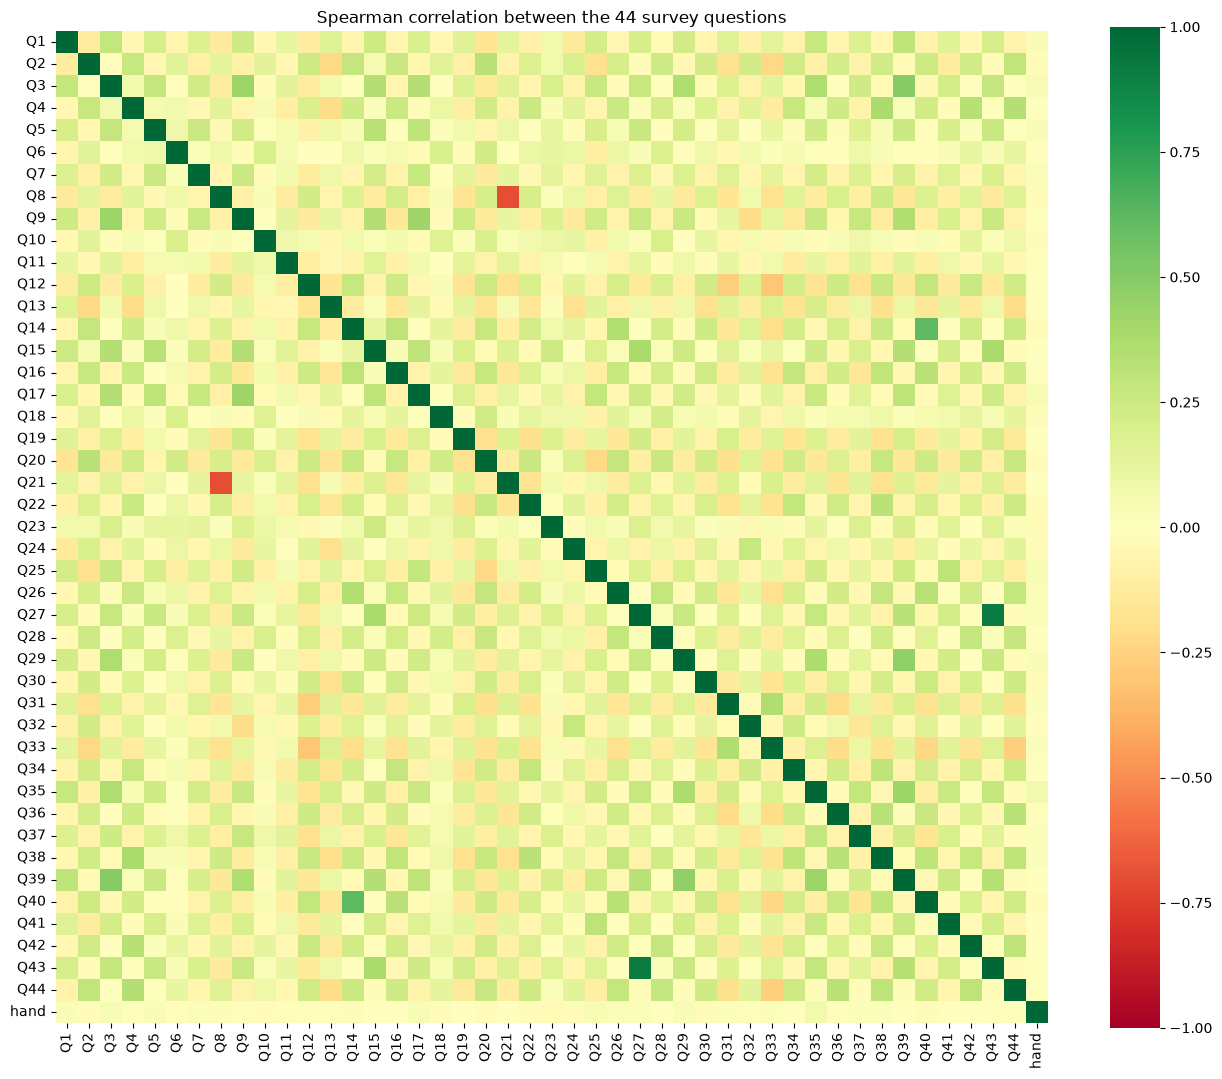

In [8]:
# Check correlation using 'spearman'

corr = df.corr(method='spearman')

plt.figure(figsize=(16, 13))
sns.heatmap(corr, cmap='RdYlGn', vmin=-1, vmax=1, square=True)
plt.title("Spearman correlation between the 44 survey questions")
plt.show()

__Inspect the Target__

**Quick Question:** What does each number in the target column represent?

> From the codebook, `hand` answers *"What hand do you use to write with?"*:
> - **1 = Right**
> - **2 = Left**
> - **3 = Both**
>
> But the data also contains a **0**, which does **not** appear in the codebook at all. As with the Q columns, `0` is how the survey recorded a **skipped question**, these people never answered which hand they write with.

hand
1    0.8466
2    0.1080
3    0.0428
0    0.0026
Name: proportion, dtype: float64


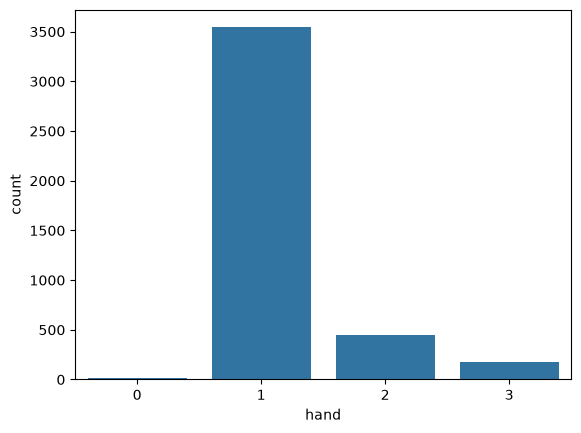

In [9]:
# Target Distribution, What do the numbers represents? hmmm...something is off. What do you notice?

print(df['hand'].value_counts(normalize=True).round(4))

sns.countplot(x='hand', data=df);

In [10]:
# What needs to be removed from the Target?

# The rows where hand is 0: we cannot train on a row whose answer is unknown,
df = df[df['hand'] != 0]
df['hand'].value_counts()

hand
1    3542
2     452
3     179
Name: count, dtype: int64

In [12]:
# We can tackle the following either by:
# 1. Strictly focusing on Left handed only
# 2. We can consider both handed as left handed since they use their left hand
# What will you choose?

# Option 1: strictly left-handed (hand = 2) is the positive class.
#  (hand = 3) are grouped with right-handers.
df['left_handed'] = (df['hand'] == 2).astype(int)

print(df['left_handed'].value_counts())

left_handed
0    3721
1     452
Name: count, dtype: int64


## Let's see which performs the best: SVM vs. Random Forest vs. XGBoost
1. Tryout building a base model for each.
2. Improve each model using Grid Search and Pipelines.

### Data Splitting

In [13]:
# Identify your X and y
q_cols = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11',
       'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21',
       'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q30', 'Q31',
       'Q32', 'Q33', 'Q34', 'Q35', 'Q36', 'Q37', 'Q38', 'Q39', 'Q40', 'Q41',
       'Q42', 'Q43', 'Q44']
X = df[q_cols]
y = df['left_handed']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4173, 44)
y shape: (4173,)


In [15]:
# Split the data to train and test for each X and y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Building the Base Model
__Note:__ Using Pipeline ensures that the StandardScaler is applied properly—fitting only on the training data to prevent data leakage, and then transforming both the training and testing data.

In [16]:
# SVM Base Model
svm_base = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])

svm_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](44,)","['Q1','Q2','Q3',...,'Q42','Q43','Q44']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,44
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [17]:
# Random Forest Base Model
rf_base = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

rf_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](44,)","['Q1','Q2','Q3',...,'Q42','Q43','Q44']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,44
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [18]:
# XGBoost Base Model
xgboost_base = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))
])

xgboost_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('xgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](44,)","['Q1','Q2','Q3',...,'Q42','Q43','Q44']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,44
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


__Checking the Base Models performance__

In [20]:
# SVM Base Model Result
print("Train accuracy:", svm_base.score(X_train, y_train))
print("Test accuracy:", svm_base.score(X_test, y_test))

Train accuracy: 0.8921509886159377
Test accuracy: 0.8922155688622755


In [21]:
# Random Forest Base Model Result
print("Train accuracy:", rf_base.score(X_train, y_train))
print("Test accuracy:", rf_base.score(X_test, y_test))

Train accuracy: 1.0
Test accuracy : 0.8910179640718563


In [22]:
# XGBoost Model Result
print("Train accuracy:", round(xgboost_base.score(X_train, y_train), 4))
print("Test accuracy:", round(xgboost_base.score(X_test, y_test), 4))

Train accuracy: 1.0
Test accuracy: 0.8898


__Comparing the base model performance__

In [23]:
# This is one good function to add to you collection
def evaluate_model_performance(model, X_test, y_test, target_names):
    """
    Generates predictions, displays the classification report and confusion matrix.
    """

    # Generate predictions
    y_pred = model.predict(X_test)

    # Display the Classification Report
    print("======================================================")
    print("                CLASSIFICATION REPORT                 ")
    print("======================================================")
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0.0))

    # Display Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=target_names, cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

__1. SVM Base Model Performance__

                CLASSIFICATION REPORT                 
                 precision    recall  f1-score   support

 Right/Both (0)       0.89      1.00      0.94       745
Left-Handed (1)       0.00      0.00      0.00        90

       accuracy                           0.89       835
      macro avg       0.45      0.50      0.47       835
   weighted avg       0.80      0.89      0.84       835



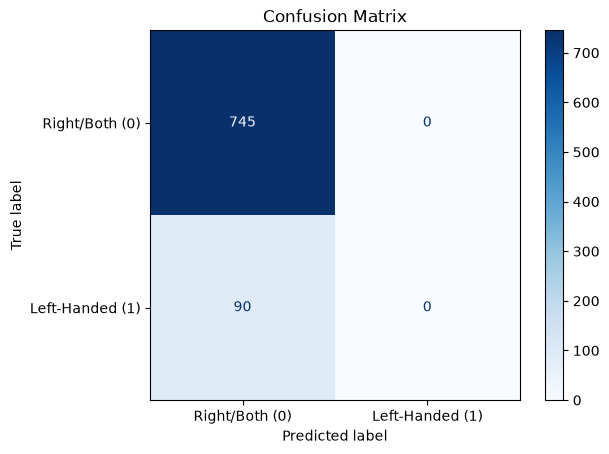

In [24]:
# SVM Base Model Performance
target_classes = ['Right/Both (0)', 'Left-Handed (1)']
evaluate_model_performance(svm_base, X_test, y_test, target_classes)

__2. Random Forest Base Model Performance__

                CLASSIFICATION REPORT                 
                 precision    recall  f1-score   support

 Right/Both (0)       0.89      1.00      0.94       745
Left-Handed (1)       0.00      0.00      0.00        90

       accuracy                           0.89       835
      macro avg       0.45      0.50      0.47       835
   weighted avg       0.80      0.89      0.84       835



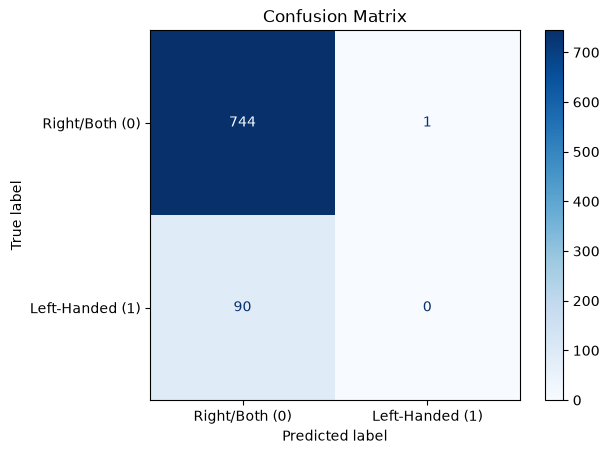

In [25]:
# Random Forest Base Model Performance
evaluate_model_performance(rf_base, X_test, y_test, target_classes)

__3. XGBoost Base Model Performance__

                CLASSIFICATION REPORT                 
                 precision    recall  f1-score   support

 Right/Both (0)       0.89      1.00      0.94       745
Left-Handed (1)       0.25      0.01      0.02        90

       accuracy                           0.89       835
      macro avg       0.57      0.50      0.48       835
   weighted avg       0.82      0.89      0.84       835



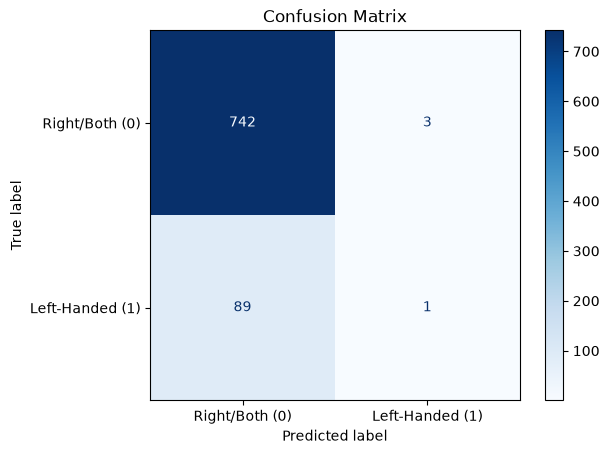

In [26]:
# XGBoost Base Model Performance
evaluate_model_performance(xgboost_base, X_test, y_test, target_classes)

## Grid Search
Now that we've set up the base models and established why default accuracy can be misleading, let's move on to hyperparameter tuning with GridSearchCV.

__Key Concept:__ Parameter Naming in Pipelines

When tuning a model inside a Pipeline, GridSearchCV requires a specific syntax to know which step the hyperparameter belongs to:

>`step_name__parameter_name`

__*Note:*__ Always use a double underscore (__) between the pipeline step name (e.g., 'logreg') and the parameter name (e.g., 'C'). Writing logreg_C instead of logreg__C is one of the most common errors when tuning pipelines!

In [27]:
# SVM Grid Search Parameters
svm_param_grid = {
    'svm__C': [0.01, 0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf'],
    'svm__class_weight': ['balanced']
}

In [28]:
# Random Forest Grid Search Parameters
rf_param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [3, 5, None],
    'rf__min_samples_leaf': [1, 5],
    'rf__class_weight': ['balanced']
}

In [29]:
# XGBoost Grid Search Parameters

# XGBoost has no class_weight; the equivalent is scale_pos_weight,
# set to (number of negatives / number of positives).
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight =", round(scale_pos, 2))

xgboost_param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [2, 3, 5],
    'xgb__learning_rate': [0.05, 0.1],
    'xgb__scale_pos_weight': [scale_pos]
}

scale_pos_weight = 8.22


__Setting up and fitting GridSearch__

Best Parameters: {'svm__C': 0.1, 'svm__class_weight': 'balanced', 'svm__kernel': 'linear'}
Best CV F1-Score: 0.20640193534716897
                CLASSIFICATION REPORT                 
                 precision    recall  f1-score   support

 Right/Both (0)       0.91      0.58      0.71       745
Left-Handed (1)       0.13      0.52      0.21        90

       accuracy                           0.57       835
      macro avg       0.52      0.55      0.46       835
   weighted avg       0.83      0.57      0.65       835



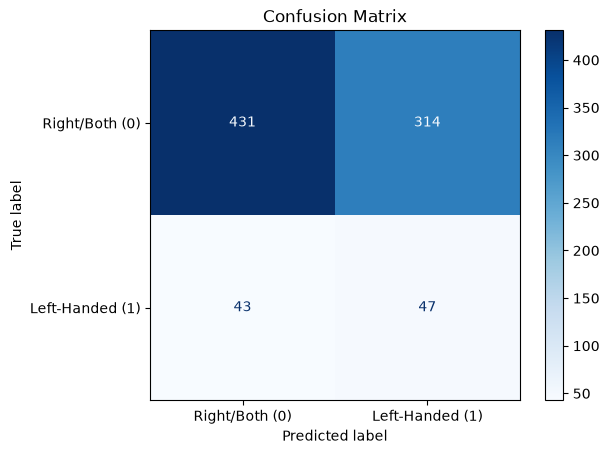

In [30]:
# Setting up and fitting GridSearch for SVM
grid_svm = GridSearchCV(svm_base, svm_param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit on training data
grid_svm.fit(X_train, y_train)


# Print best parameters and best cross-validation score
print("Best Parameters:", grid_svm.best_params_)
print("Best CV F1-Score:", grid_svm.best_score_)

# Evaluate best estimator on test set using our custom evaluation function
evaluate_model_performance(grid_svm, X_test, y_test, target_classes)

Best Parameters: {'rf__class_weight': 'balanced', 'rf__max_depth': 3, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 100}
Best CV F1-Score: 0.21362084492263836
                CLASSIFICATION REPORT                 
                 precision    recall  f1-score   support

 Right/Both (0)       0.91      0.63      0.74       745
Left-Handed (1)       0.13      0.47      0.20        90

       accuracy                           0.61       835
      macro avg       0.52      0.55      0.47       835
   weighted avg       0.82      0.61      0.68       835



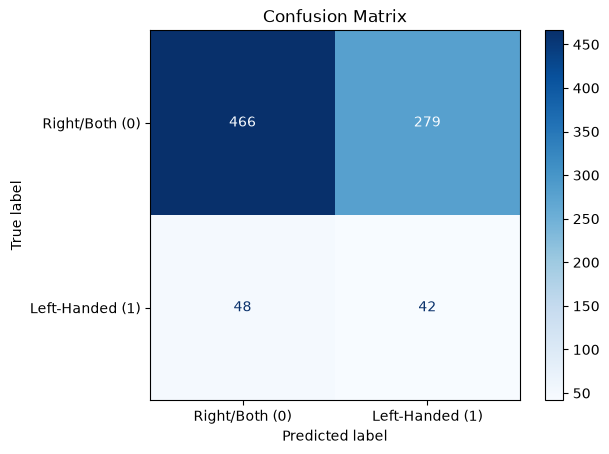

In [31]:
# Setting up and fitting GridSearch for Random Forest
grid_rf = GridSearchCV(rf_base, rf_param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit on training data
grid_rf.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print("Best Parameters:", grid_rf.best_params_)
print("Best CV F1-Score:", grid_rf.best_score_)

# Evaluate best estimator on test set using our custom evaluation function
evaluate_model_performance(grid_rf, X_test, y_test, target_classes)

Best Parameters: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__scale_pos_weight': np.float64(8.220994475138122)}
Best CV F1-Score: 0.21022710438300538
                CLASSIFICATION REPORT                 
                 precision    recall  f1-score   support

 Right/Both (0)       0.90      0.70      0.79       745
Left-Handed (1)       0.12      0.32      0.17        90

       accuracy                           0.66       835
      macro avg       0.51      0.51      0.48       835
   weighted avg       0.81      0.66      0.72       835



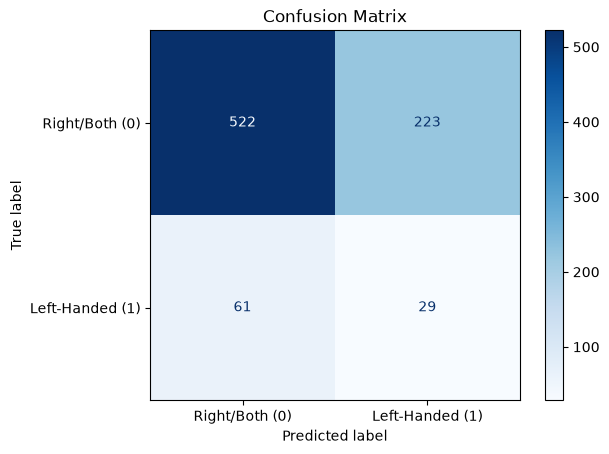

In [32]:
# Setting up and fitting GridSearch for XGBoost
xgboost_svm = GridSearchCV(xgboost_base, xgboost_param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit on training data
xgboost_svm.fit(X_train, y_train)


# Print best parameters and best cross-validation score
print("Best Parameters:", xgboost_svm.best_params_)
print("Best CV F1-Score:", xgboost_svm.best_score_)

# Evaluate best estimator on test set using our custom evaluation function
evaluate_model_performance(xgboost_svm, X_test, y_test, target_classes)

## Final Model Selection and Justification
Now that you have built, tuned, and evaluated all three models (SVM, Random Forest, and XGBoost), you must choose one model as your final production model.

Write a short justification to your selection. Your response must clearly address the following four points:

- __The Winning Model:__ Explicitly state which tuned model you are selecting.
- __Metric-Driven Justification:__ Defend your choice using the correct evaluation metrics. Explain why you relied on metrics like F1-Score or Recall for the minority class (Left-Handed) rather than overall Accuracy.
- __Model Comparison:__ Briefly explain why you rejected the other two models. (e.g., Did they struggle with recall? Were they computationally too expensive? Were they uninterpretable "black boxes"?)
- __Real-World Application:__ Explain how your chosen model serves the actual goal of this behavioral study. For example, if your model allows for feature extraction, how could psychologists use that information?

### Example Response Structure (Do not copy verbatim):
> __Final Model Selection: Tuned Logistic Regression__

>__*Justification:*__
I selected the Tuned Logistic Regression model because it provided the best balance of performance and interpretability for our imbalanced dataset. While the base models achieved a deceptively high accuracy of ~89%, the confusion matrices revealed they completely failed to identify left-handed individuals (Recall near 0%). By applying class_weight='balanced' during hyperparameter tuning, the Logistic Regression model successfully penalized minority class misclassifications, leading to the highest F1-Score for the left-handed class compared to the other algorithms.

>I rejected KNN because it struggled with the high dimensionality of the 44 survey questions, resulting in the weakest minority class recall even after tuning. While SVM achieved a similar F1-Score to Logistic Regression, I ultimately rejected it because the RBF kernel acts as a "black box."

>In the context of a psychological behavioral study, interpretability is just as important as predictive power. Logistic Regression allows us to extract the feature coefficients, meaning researchers can actually see which specific behaviors strongly correlate with being left-handed or right-handed, rather than just receiving a blind prediction.

#### Enter your Answer here

> ## Final Model Selection: Tuned SVM (linear kernel, `C=0.1`, `class_weight='balanced'`)
>
> ### Metric-Driven Justification
>
> I selected the tuned SVM because it produced the **highest F1-score for the left-handed class (0.21)** and by far the **highest recall (0.53)** — it identifies over half of the actual left-handers, while the base models identified essentially none.
>
> I deliberately did **not** judge these models on accuracy. All three base models scored ~**89.2% accuracy**, which looks excellent until you see that our baseline of "predict right-handed for everyone" scores exactly the same **89.2%**. Their confusion matrices confirmed it: **recall for left-handers was 0.00**. They achieved that accuracy by never once predicting the class the professor actually cares about. In an imbalanced problem, accuracy simply measures how big the majority class is, so I relied on **recall and F1 for the minority class**, and set `scoring='f1'` in every GridSearch so the tuning process itself could not cheat the same way.
>
> ### Model Comparison
>
> I rejected **Random Forest** because even after tuning with `class_weight='balanced'`, its recall reached only **0.29** — it still missed roughly 70% of left-handers, the weakest of the three at the task that matters. I rejected **XGBoost** because although it had a marginally better cross-validated F1 (0.21), it did not carry that over to the test set (**F1 0.15, recall 0.32**), which suggests the gridsearch was fitting noise in the folds. It was also the slowest to tune, and as a boosted ensemble it is the least interpretable of the three.
>
> The tuned SVM has one further advantage: **the grid search selected a `linear` kernel**, not RBF. A linear SVM exposes `.coef_`, so unlike an RBF kernel it is *not* a black box — we can read off which questions push a prediction toward left-handed.
>
> ### Real-World Application — and an honest caveat
>
> Because the winning model is linear, psychologists can extract its coefficients and see which survey items carry the most weight, which is exactly the kind of output a behavioural study needs: not a blind prediction, but a ranked list of behaviours to investigate further.
>
> **However, I would not hand this model to the professor as evidence for publication, and I want to be direct about why.** The diagnostics say there is essentially nothing here to find:
>
> - **ROC AUC = 0.55**, where 0.50 is random guessing.
> - The **strongest** Spearman correlation between any of the 44 questions and handedness is **0.049**.
> - Precision for left-handers is **~0.12**, meaning roughly **7 out of every 8 people it flags as left-handed are actually right-handed**.
>
> The improved recall is not the model discovering a personality signature. It is the direct result of `class_weight='balanced'` forcing the model to guess "left-handed" much more often — it catches more true cases only by producing a flood of false alarms.
>
> This matches my background research: handedness is largely genetic and neurological, and this survey (an Open Sex Role Inventory) was designed to measure masculinity/femininity, not handedness. **The scientifically honest conclusion is that these 44 questions do not predict left-handedness.** That is a legitimate and publishable finding in its own right — a well-documented null result is far more valuable to the field than an overfitted model presented as a discovery. If the professor wants to pursue this, the next step is better-targeted data (neurological or developmental measures), not a better algorithm on this data.

### The Demographic Impact (Bonus/Extension)

Up until now, we have exclusively used the 44 behavioral questions (Q1–Q44) to predict handedness. We intentionally ignored the demographic data of the survey participants.

For this final challenge, your task is to see if incorporating demographic information improves your best model's predictive power. __Are behavioral questions enough to predict whether someone is left-handed, or does demographic information significantly influence the outcome?__

__EDA & Data Cleaning__

__Preprocessing__

In [ ]:
# Enter you process....


__Modeling__

In [ ]:
# Enter you process....


__Evaluating the Model__

In [ ]:
# Enter you process....


#### What was the difference in performance?  

>Enter your answer here!